In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets  # load_iris() 함수 사용하기 위해서
from sklearn.model_selection import train_test_split  # 훈련 셋/테스트 셋 분리 함수
from sklearn.preprocessing import StandardScaler  # 특성 스케일링 클래스
from sklearn.neighbors import KNeighborsClassifier  # KNN 모델 클래스
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split  # 훈련/테스트 셋 분리 함수
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
tips=sns.load_dataset('tips')

In [3]:
tips.shape

(244, 7)

In [4]:
for x in tips.columns:
  print(x)

total_bill
tip
sex
smoker
day
time
size


In [5]:
tips.total_bill.value_counts()

,count
total_bill,
13.42,3
21.01,2
20.69,2
10.33,2
10.34,2
...,...
29.03,1
27.18,1
22.67,1


In [6]:
tips['size'].value_counts()

,count
size,
2,156
3,38
4,37
5,5
1,4
6,4


In [7]:
tips.total_bill.max()

50.81

In [8]:
tips[tips.total_bill==tips.total_bill.max()]

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.0,Male,Yes,Sat,Dinner,3


In [9]:
tips[tips.sex=='Male'].tip.mean()

np.float64(3.0896178343949043)

In [10]:
tips[tips.tip>tips.tip.mean()]

,total_bill,tip,sex,smoker,day,time,size
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
7,26.88,3.12,Male,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
232,11.61,3.39,Male,No,Sat,Dinner,2
234,15.53,3.00,Male,Yes,Sat,Dinner,2
238,35.83,4.67,Female,No,Sat,Dinner,3
239,29.03,5.92,Male,No,Sat,Dinner,3


In [11]:
tips['tip_ratio']=(tips.tip/tips.total_bill)

In [12]:
tips

,total_bill,tip,sex,smoker,day,time,size,tip_ratio
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.203927
240,27.18,2.00,Female,Yes,Sat,Dinner,2,0.073584
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.088222
242,17.82,1.75,Male,No,Sat,Dinner,2,0.098204


In [13]:
asd=tips[tips['tip_ratio']>tips['tip_ratio'].mean()]

In [14]:
asd.sex.value_counts()/tips.sex.value_counts()

,count
sex,
Male,0.420382
Female,0.471264


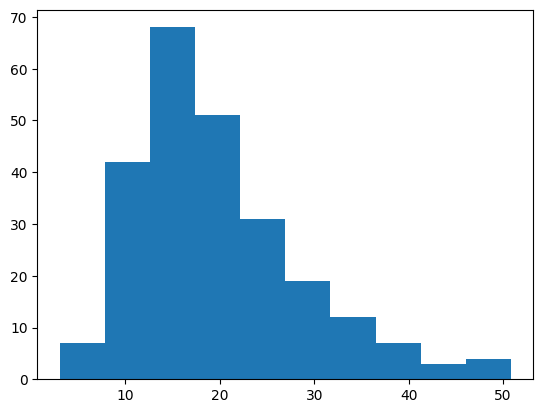

In [15]:
fig= plt.figure()
axis=fig.add_subplot(111)
axis.hist(x=tips.total_bill)
plt.show()

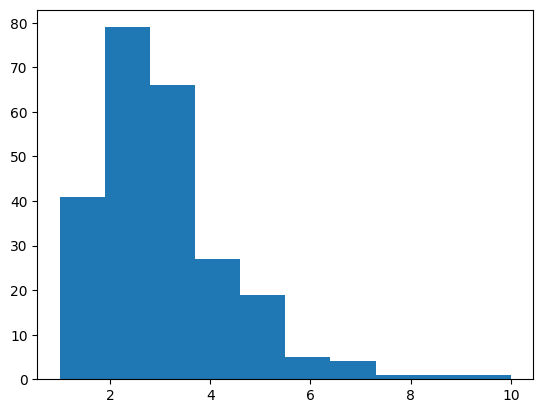

In [16]:
fig, axis= plt.subplots()

axis.hist(x=tips.tip)

plt.show()

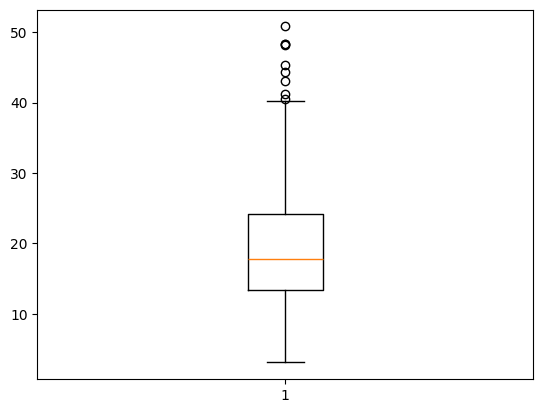

In [17]:
plt.boxplot(x=tips.total_bill)
plt.show()

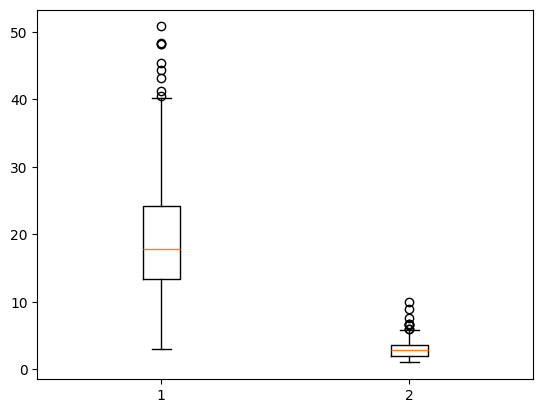

In [18]:
plt.boxplot(x=[tips.total_bill,tips.tip])
plt.show()

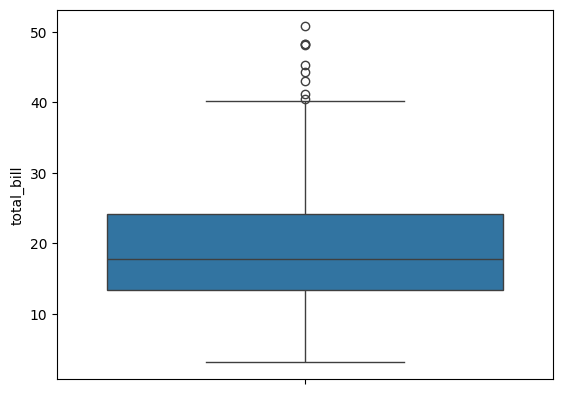

In [19]:
sns.boxplot(data=tips,y='total_bill')
plt.show()

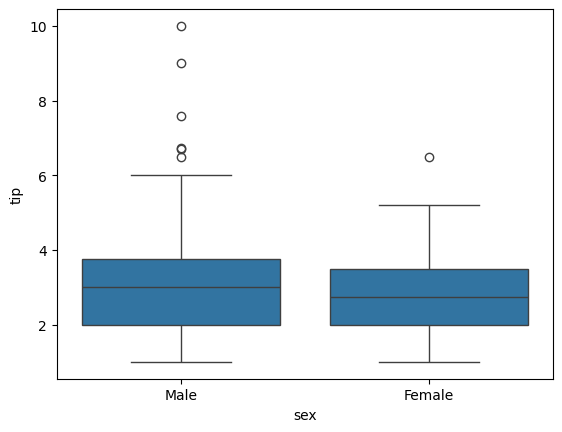

In [20]:
sns.boxplot(data=tips,x='sex',y='tip')
plt.show()

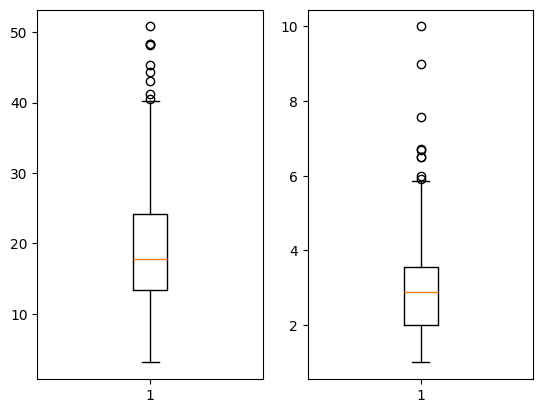

In [21]:
fig, axes= plt.subplots(nrows=1,ncols=2)

axes[0].boxplot(x=tips.total_bill)
axes[1].boxplot(x=tips.tip)

plt.show()

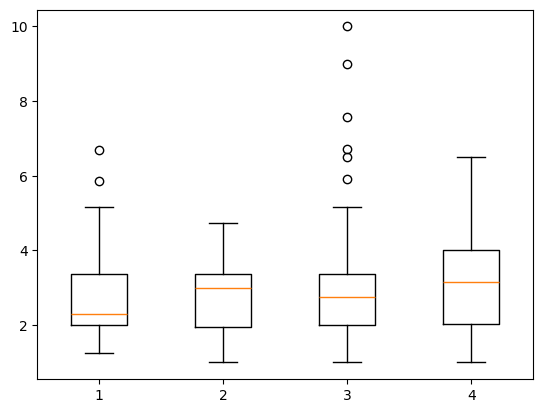

In [22]:
day_category=tips.day.cat.categories
data=[]
for x in day_category:
  tip_by_day=tips[tips.day==x].tip
  data.append(tip_by_day)
plt.boxplot(x=data)
plt.show()

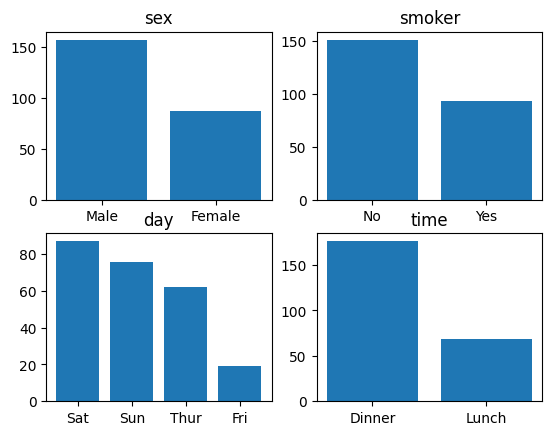

In [23]:
titles=[['sex','smoker'],['day','time']]

fig,axes=plt.subplots(nrows=2,ncols=2)

for i, row in enumerate(titles):
  for j, t in enumerate(row):
    data=tips[t].value_counts()
    axes[i,j].bar(x=data.index,height=data.values)
    axes[i,j].set_title(t)
plt.show()
# titles=[['sex','smoker'],['day','time']]

# fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(8,8))

# for i,row in enumerate(titles): # i앞인덱스
#   for j, t in enumerate(row): # j뒤인덱스 t타이틀
#     # print(i,j,t)
#     data=tips[t].value_counts() # titles이 list로 되어있어서 = [t]
#     axes[i,j].bar(x=data.index,height=data.values)
#     axes[i,j].set_title(t)
# plt.show()

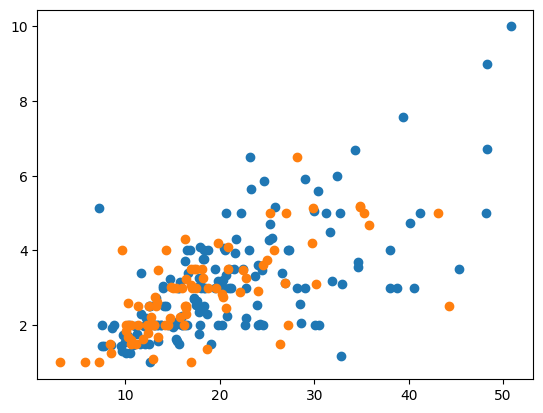

In [24]:
male_df=tips[tips.sex=='Male']
female_df=tips[tips.sex=='Female']

plt.scatter(x=male_df.total_bill,y=male_df.tip)
plt.scatter(x=female_df.total_bill,y=female_df.tip)

plt.show()

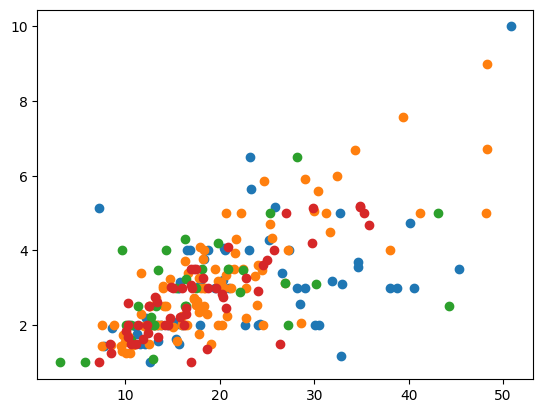

In [25]:
gender=tips.sex.cat.categories
smoker=tips.smoker.cat.categories
colors = ['DodgerBlue', 'IndianRed']
markers= ['o', 'v']

for g,c in zip(gender,colors):
  for s,m in zip(smoker,markers):
    df=tips[(tips.sex==g)&(tips.smoker==s)]
    plt.scatter(x=df.total_bill,y=df.tip)
plt.show()

In [26]:
np.random.seed(1) # 실행할 때마다 같은 난수들이 만들어 지도록 하기 위해서.
df = pd.DataFrame(data={
    'day':np.arange(1,11),
    'price':np.random.rand(10),

})
df

,day,price
0,1,0.417022
1,2,0.720324
2,3,0.000114
3,4,0.302333
4,5,0.146756
5,6,0.092339
6,7,0.186260
7,8,0.345561
8,9,0.396767
9,10,0.538817


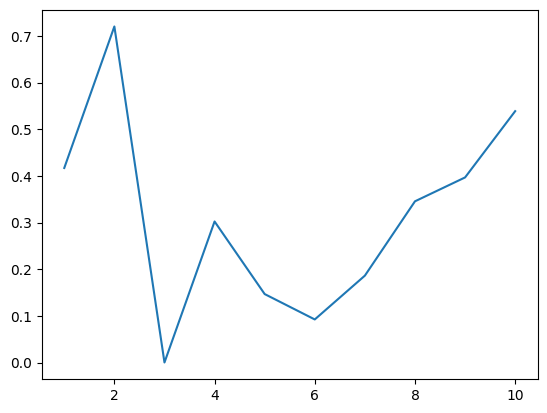

In [27]:
plt.plot(df.day,df.price)
plt.show()

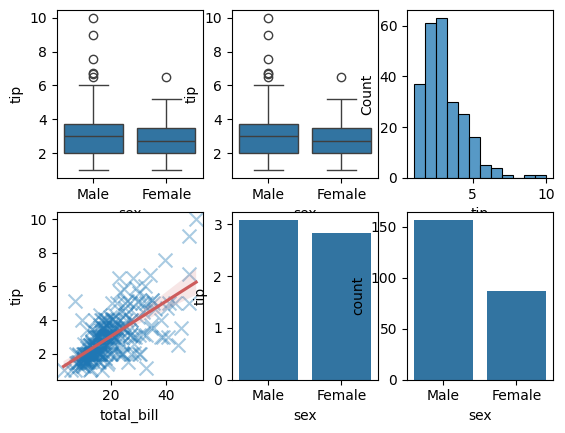

In [28]:
fig, axes=plt.subplots(nrows=2,ncols=3)
sns.boxplot(data=tips,x='sex',y='tip',ax=axes[0][0])
sns.boxplot(data=tips,x='sex',y='tip',ax=axes[0][1])
sns.histplot(data=tips, x='tip',bins=12,ax=axes[0][2])
sns.countplot(data=tips,x='sex',ax=axes[1][2])#빈도수
sns.barplot(data=tips, x='sex',y='tip',errorbar=None,ax=axes[1][1])#기본 mean estimator=max등 변경가능
sns.regplot(data=tips, x='total_bill',y='tip',marker='x',ax=axes[1][0],
            scatter_kws={'alpha':0.378895,'s':100},line_kws={'color':'IndianRed'})
plt.show()

In [29]:
tips.groupby(by=['day','sex'],observed=True).sex.count()

day   sex   
Thur  Male      30
      Female    32
Fri   Male      10
      Female     9
Sat   Male      59
      Female    28
Sun   Male      58
      Female    18
Name: sex, dtype: int64

In [30]:
iris= sns.load_dataset('iris')

In [31]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [32]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


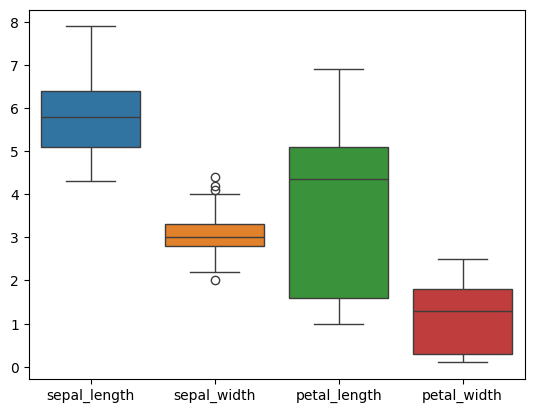

In [33]:
sns.boxplot(data=iris)
plt.show()

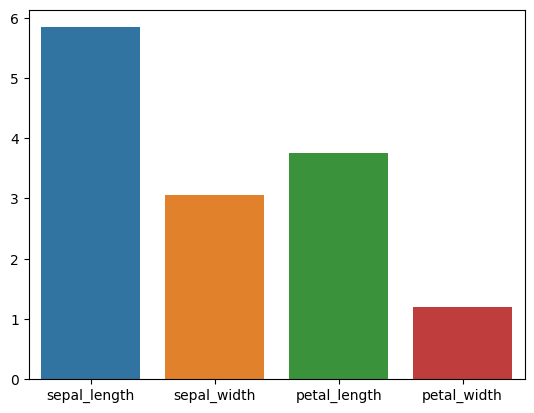

In [34]:
sns.barplot(data=iris,errorbar=None)
plt.show()

In [35]:
iris[iris.columns[:-1]].mean()

,0
sepal_length,5.843333
sepal_width,3.057333
petal_length,3.758000
petal_width,1.199333


In [36]:
iris.species.value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


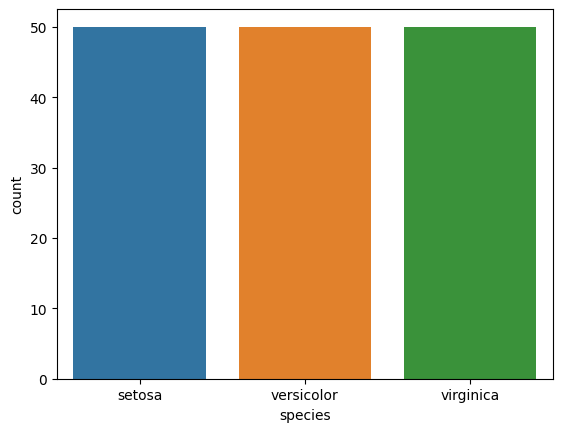

In [37]:
sns.countplot(data=iris,x='species',hue='species')
plt.show()

In [38]:
seto=iris[iris.species=='setosa']
vers=iris[iris.species=='versicolor']
virg=iris[iris.species=='virginica']

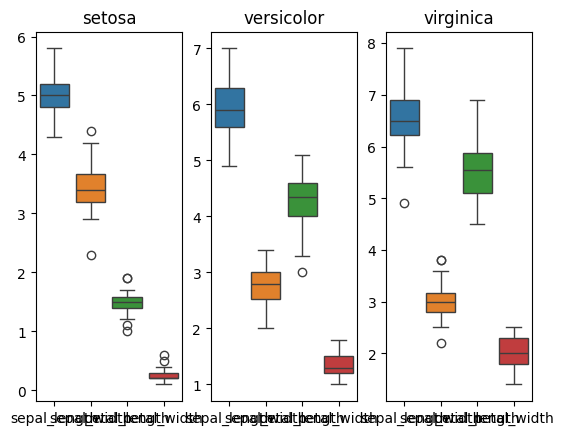

In [39]:
jongryu=iris.species.unique()

fig,axes=plt.subplots(ncols=3)

for i, s in enumerate(jongryu):
  data=iris[iris.species==s]
  sns.boxplot(data=data,ax=axes[i])
  axes[i].set_title(s)
plt.show()

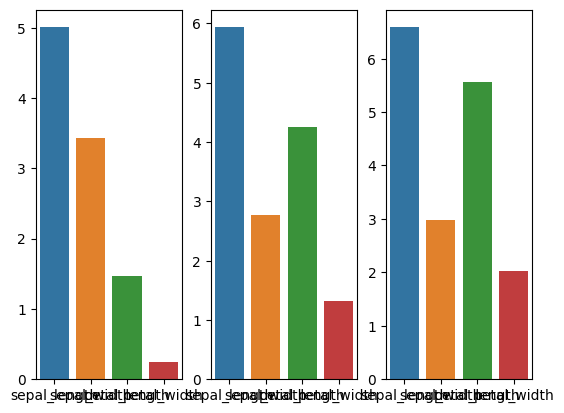

In [40]:
jongryu=iris.species.unique()

fig,axes=plt.subplots(ncols=3)

for i, s in enumerate(jongryu):
  data=iris[iris.species==s]
  sns.barplot(data=data, ax=axes[i],errorbar=None)
plt.show()

# day_category=tips.day.cat.categories #matplotlib은 빈리스트를 받아야한다
# data=[]
# for x in day_category:
#   tip_by_day=tips[tips.day==x].tip
#   data.append(tip_by_day)
# plt.boxplot(x=data)
# plt.show()

In [41]:
iris.groupby(by=['species'],observed=True)[iris.columns[:-1]].mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


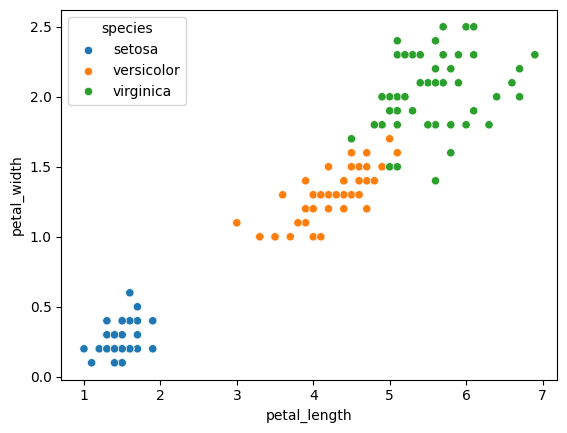

In [42]:
sns.scatterplot(data=iris, x='petal_length',y='petal_width',hue='species')
plt.show()

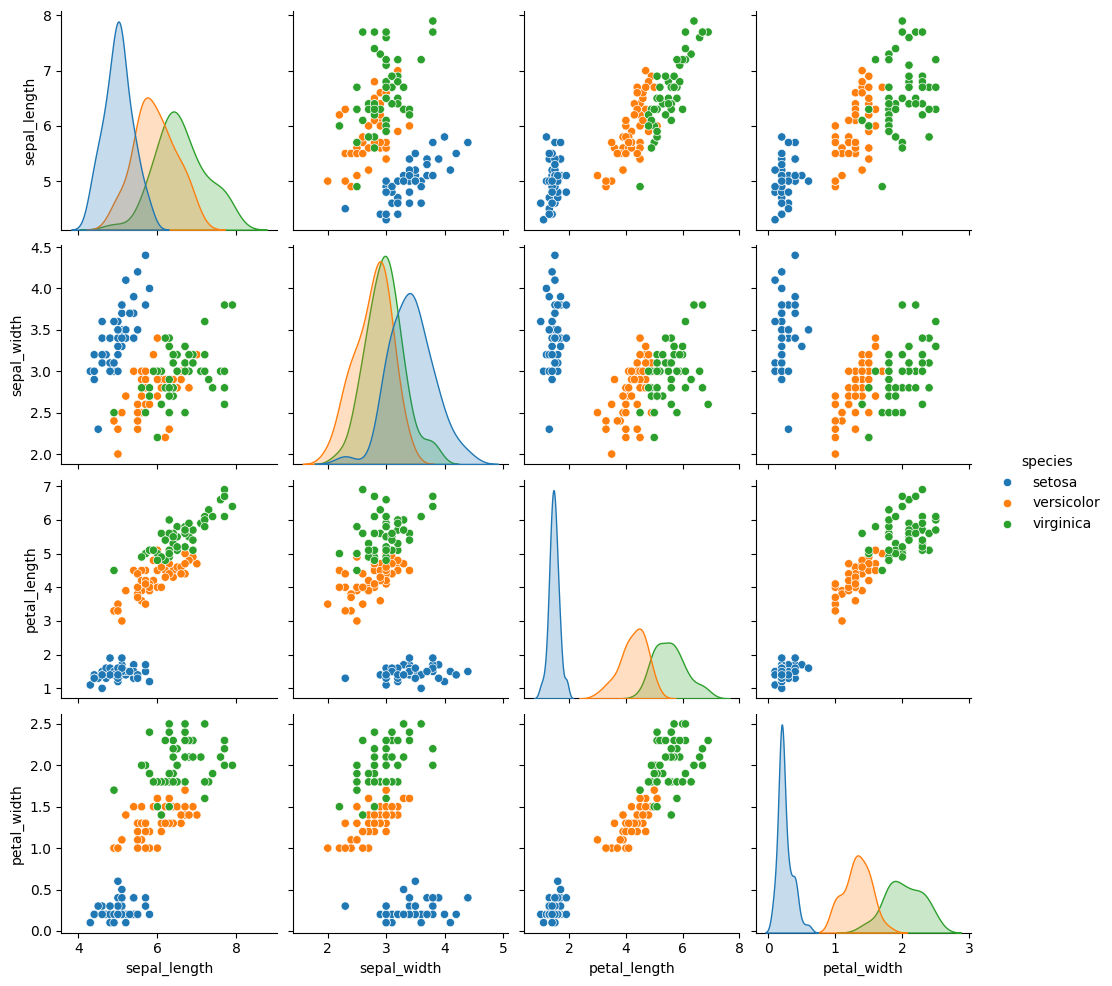

In [43]:
sns.pairplot(data=iris,hue='species')
plt.show()

In [44]:
mpg = sns.load_dataset('mpg')

In [45]:
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [46]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [47]:
asd=mpg.model_year.value_counts().sort_index()

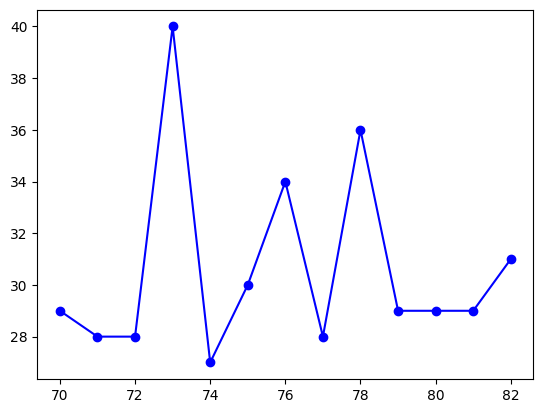

In [48]:
plt.plot(asd.index, asd.values, 'bo-')
plt.show()

In [49]:
file_path='https://raw.githubusercontent.com/JakeOh/202511_BD53/refs/heads/main/datasets/gapminder.tsv'

In [50]:
gapm=pd.read_csv(file_path,sep='\t')

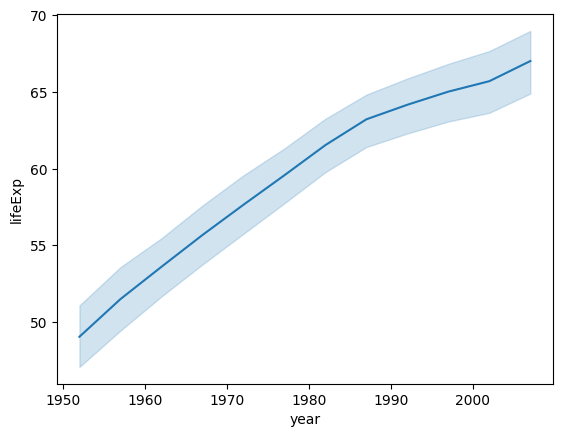

In [51]:
sns.lineplot(data=gapm,x='year',y='lifeExp')
plt.show()

<Axes: >

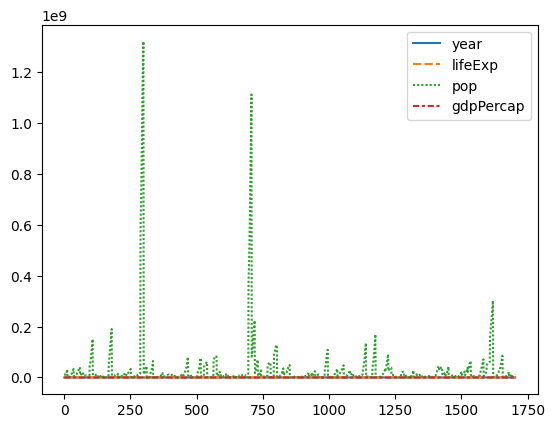

In [52]:
sns.lineplot(data=gapm,)

In [53]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [54]:
print(type(iris))

<class 'pandas.core.frame.DataFrame'>


In [55]:
iris=datasets.load_iris()

In [56]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [57]:
X=iris.data

In [58]:
y=iris.target

In [59]:
np.unique(y,return_counts=True)

(array([0, 1, 2]), array([50, 50, 50]))

In [60]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [61]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [62]:
result=datasets.load_iris(as_frame=True)
result.frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [63]:
iris=sns.load_dataset('iris')

In [64]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [65]:
X=iris[['sepal_length','sepal_width']].values

In [66]:
X[:50,:]

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1],
       [5.4, 3.7],
       [4.8, 3.4],
       [4.8, 3. ],
       [4.3, 3. ],
       [5.8, 4. ],
       [5.7, 4.4],
       [5.4, 3.9],
       [5.1, 3.5],
       [5.7, 3.8],
       [5.1, 3.8],
       [5.4, 3.4],
       [5.1, 3.7],
       [4.6, 3.6],
       [5.1, 3.3],
       [4.8, 3.4],
       [5. , 3. ],
       [5. , 3.4],
       [5.2, 3.5],
       [5.2, 3.4],
       [4.7, 3.2],
       [4.8, 3.1],
       [5.4, 3.4],
       [5.2, 4.1],
       [5.5, 4.2],
       [4.9, 3.1],
       [5. , 3.2],
       [5.5, 3.5],
       [4.9, 3.6],
       [4.4, 3. ],
       [5.1, 3.4],
       [5. , 3.5],
       [4.5, 2.3],
       [4.4, 3.2],
       [5. , 3.5],
       [5.1, 3.8],
       [4.8, 3. ],
       [5.1, 3.8],
       [4.6, 3.2],
       [5.3, 3.7],
       [5. , 3.3]])

In [67]:
X[:6,:1]

array([[5.1],
       [4.9],
       [4.7],
       [4.6],
       [5. ],
       [5.4]])

In [68]:
y=iris['species'].values

In [69]:
y[:50]

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa'], dtype=object)

In [70]:
y[-5:]

array(['virginica', 'virginica', 'virginica', 'virginica', 'virginica'],
      dtype=object)

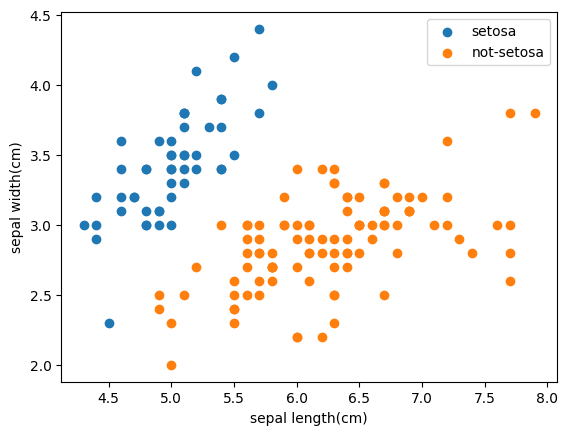

In [71]:
plt.scatter(x=X[:50, 0], y=X[:50, 1], label='setosa')
plt.scatter(x=X[50:, 0], y=X[50:, 1], label='not-setosa')

plt.legend()
plt.xlabel('sepal length(cm)')
plt.ylabel('sepal width(cm)')
plt.show()

In [72]:
knn_clf=KNeighborsClassifier()

In [73]:
knn_clf.fit(X,y)

KNeighborsClassifier()

In [74]:
y_pred=knn_clf.predict(X)

In [75]:
y_pred

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'virginica', 'virginica', 'virginica',
       'versicolor', 'virginica', 'versicolor', 'virginica', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'virginica',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'virginica', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'virginica', 'versicolor', 'virginica',
       'virginica', 'versicolor', 'virginica', 'versicolo

In [76]:
knn_clf.score(X,y)

0.84

In [77]:
ac=[]
kv=np.arange(1,151)
for x in kv:
  knn=KNeighborsClassifier(n_neighbors=x)
  knn.fit(X,y)
  acc=knn.score(X,y)
  ac.append(acc)
print(ac)


[0.92, 0.8533333333333334, 0.8533333333333334, 0.8333333333333334, 0.84, 0.8333333333333334, 0.82, 0.8266666666666667, 0.8466666666666667, 0.84, 0.8266666666666667, 0.8333333333333334, 0.82, 0.8133333333333334, 0.82, 0.8333333333333334, 0.8066666666666666, 0.8, 0.7933333333333333, 0.7866666666666666, 0.7933333333333333, 0.7933333333333333, 0.8066666666666666, 0.8066666666666666, 0.8, 0.8133333333333334, 0.8133333333333334, 0.8133333333333334, 0.82, 0.84, 0.8333333333333334, 0.8266666666666667, 0.8266666666666667, 0.8133333333333334, 0.82, 0.8266666666666667, 0.8266666666666667, 0.8333333333333334, 0.8266666666666667, 0.8266666666666667, 0.8133333333333334, 0.82, 0.82, 0.8266666666666667, 0.8266666666666667, 0.8266666666666667, 0.8266666666666667, 0.8266666666666667, 0.8266666666666667, 0.8266666666666667, 0.8266666666666667, 0.8266666666666667, 0.8333333333333334, 0.8133333333333334, 0.8133333333333334, 0.8133333333333334, 0.8133333333333334, 0.8133333333333334, 0.8, 0.8, 0.81333333333

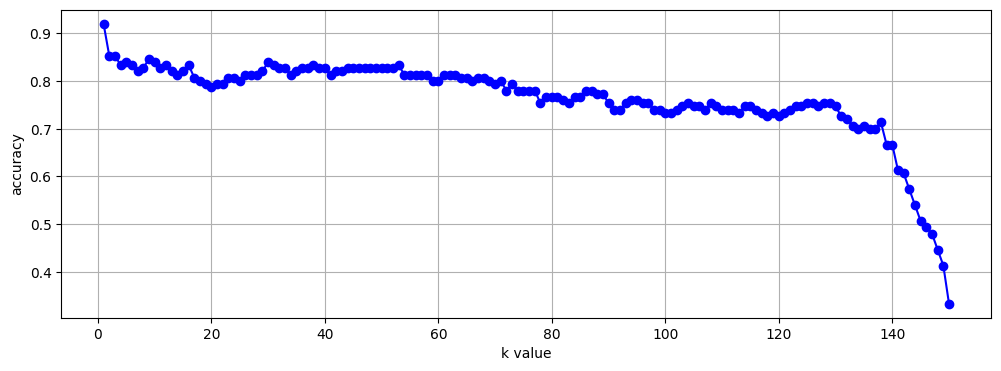

In [78]:
plt.figure(figsize=(12, 4))
plt.plot(kv, ac, 'bo-')
plt.xlabel('k value')
plt.ylabel('accuracy')
plt.grid()
plt.show()